In [2]:
!pip install PyMaxflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.2/939.2 kB 12.8 MB/s eta 0:00:00


In [34]:
import scipy.io as sio
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from pathlib import Path
from skimage import segmentation
from skimage import io, color
import skimage
import scipy.signal
import scipy
from scipy.ndimage import sobel
from google.colab.patches import cv2_imshow
import maxflow
# may need to do !pip install PyMaxflow
# https://pypi.org/project/PyMaxflow/
# faster built in method needed because we are using pixel-wise method

In [4]:
from google.colab import drive
drive.mount('/content/drive')
data_location = Path('/content/drive/MyDrive/Colab Notebooks/project/')

Mounted at /content/drive


In [5]:
# low rank subspace images (noisy)
file_name = os.path.join(data_location, 'LR_images.mat')
print("file_name:",file_name)
X = sio.loadmat(file_name)
ImLR = X['images_lowrank']

file_name: /content/drive/MyDrive/Colab Notebooks/project/LR_images.mat


In [7]:
# low rank tmaps+m0 (noisy)
file_name = os.path.join(data_location, 'Tmaps_LR.mat')
Q = sio.loadmat(file_name)
T1LR = Q['T1_lowrank']
T2LR = Q['T2_lowrank']
M0LR = Q['M0_lowrank']

In [8]:
# data from DIP (clean)
file_name = os.path.join(data_location, 'DIP_Dropout10_100Epochs_test_1.mat')

X = sio.loadmat(file_name)
T1Net = X['T1Net']
T2Net = X['T2Net']
M0Net = X['M0Net']
imNet = X['imNet']

##Normalize

In [9]:
def normalize(img):
  img_norm = np.abs(img)/np.max(np.abs(img))
  return img_norm

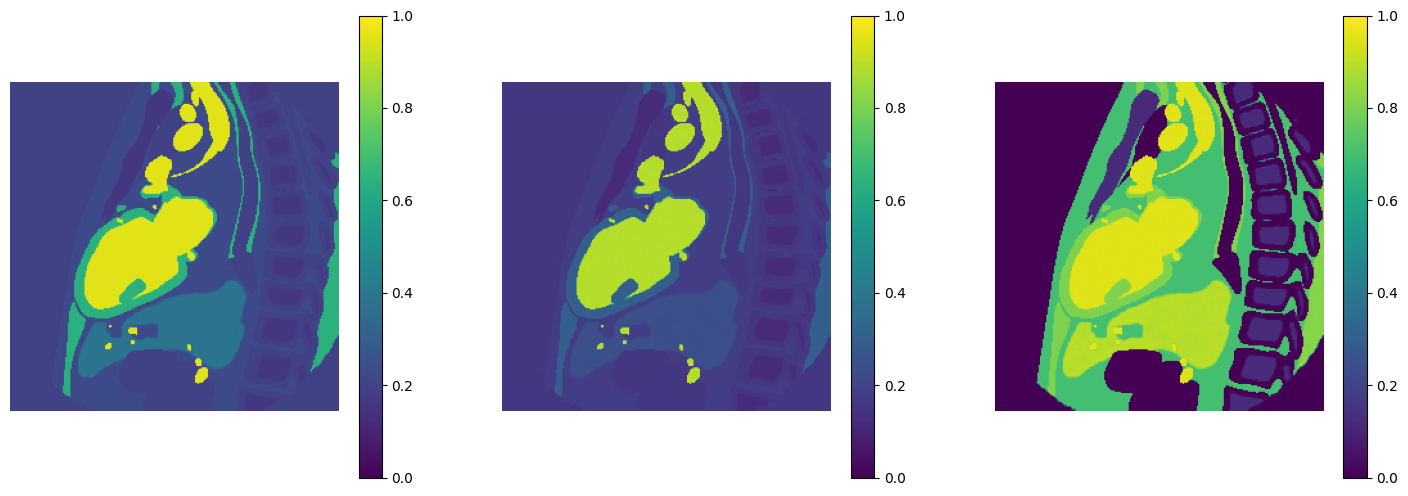

In [10]:
T1_norm = normalize(T1Net) # T1LR or T1Net
T2_norm = normalize(T2Net) # T2LR or T2Net
M0_norm = normalize(M0Net) # M0LR or M0Net

plt.figure(figsize=(18,6));
plt.subplot(1,3,1);
plt.imshow(T1_norm,vmin=0,cmap="viridis");plt.axis('off');
plt.colorbar()
plt.subplot(1,3,2);
plt.imshow(T2_norm,vmin=0,cmap="viridis");plt.axis('off');
plt.colorbar()
plt.subplot(1,3,3);
plt.imshow(M0_norm,vmin=0,vmax=1,cmap='viridis'); plt.axis('off');
plt.colorbar()
plt.show();

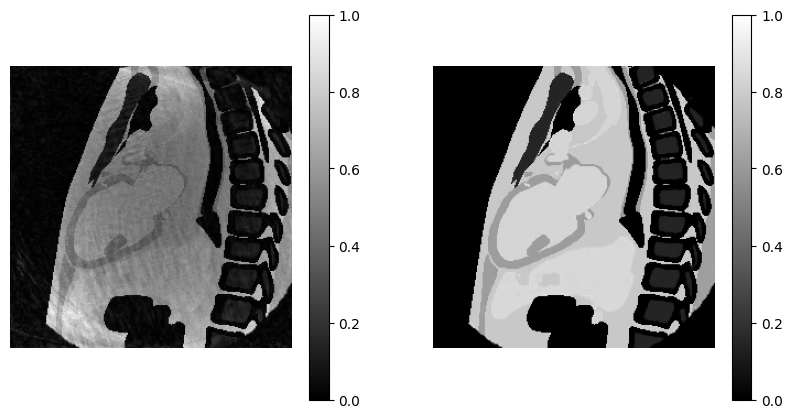

In [20]:
ImLR_norm = np.zeros_like(ImLR, dtype=float)
Im_norm = np.zeros_like(imNet, dtype=float)

for i in range(ImLR.shape[2]):
    img = np.abs(ImLR[:, :, i])
    ImLR_norm[:, :, i] = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = np.abs(imNet[:, :, i])
    Im_norm[:, :, i] = (img - img.min()) / (img.max() - img.min() + 1e-8)

# comparing clean and noisy subspace images
plt.figure(figsize=(10,5));
plt.subplot(1,2,1);
plt.imshow(ImLR_norm[:,:,0],vmin=0,cmap="gray");plt.axis('off');
plt.colorbar()
plt.subplot(1,2,2);
plt.imshow(Im_norm[:,:,0],vmin=0,cmap="gray");plt.axis('off');
plt.colorbar()
plt.show()

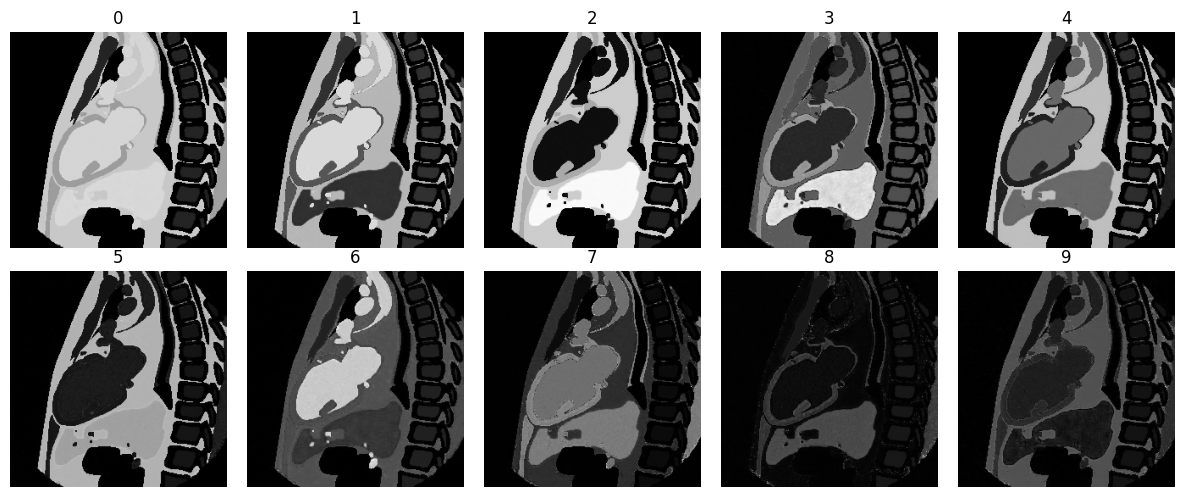

In [21]:
# Multi-contrasts images or DIP reconstructions K=10
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = np.abs(Im_norm[:, :, i])

    ax.imshow(img, vmin=0, vmax=np.max(img), cmap='gray')
    ax.axis('off')
    ax.set_title(f'{i}')

plt.tight_layout()
plt.show()

In [22]:
concat_maps = np.stack((T1_norm, T2_norm, M0_norm), axis=2)
print(concat_maps.shape)

(256, 256, 3)


## Motivation for using single pixel nodes

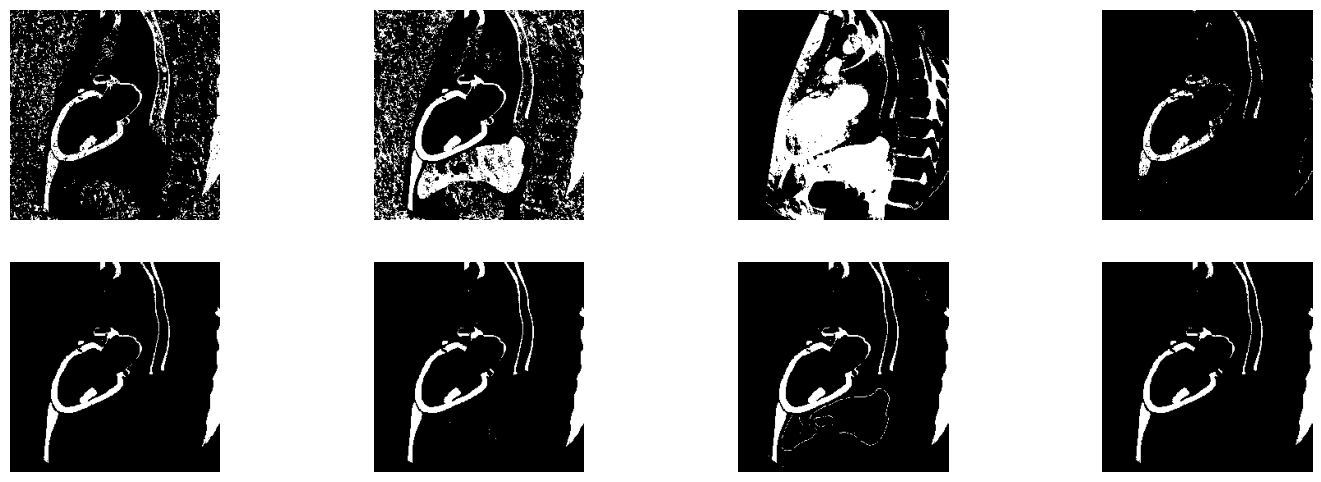

In [24]:
point = [150, 52]
Th1n = T1_norm[point[0],point[1]]
Th2n = T2_norm[point[0],point[1]]
Thmn = np.abs(M0_norm[point[0],point[1]])
Trangen = .05

Th1 = T1LR[point[0],point[1]]
Th2 = T2LR[point[0],point[1]]
Thm = np.abs(M0LR[point[0],point[1]]) # Take absolute value for M0LR
Trange = .2

maskT1n = (T1_norm >= Th1n-(Th1n*Trangen)) & (T1_norm <= Th1n+(Th1n*Trangen))
maskT2n = (T2_norm >= Th2n-(Th2n*Trangen)) & (T2_norm <= Th2n+(Th2n*Trangen))
maskM0n = (np.abs(M0_norm) >= Thmn-(Thmn*Trangen)) & (np.abs(M0_norm) <= Thmn+(Thmn*Trangen))

maskT1 = (T1LR >= Th1-(Th1*Trange)) & (T1LR <= Th1+(Th1*Trange))
maskT2 = (T2LR >= Th2-(Th2*Trange)) & (T2LR <= Th2+(Th2*Trange))
maskM0 = (np.abs(M0LR) >= Thm-(Thm*Trange)) & (np.abs(M0LR) <= Thm+(Thm*Trange)) # Apply abs() to the array for comparison
combomask = maskT1 * maskT2 * maskM0
combomaskn = maskT1n * maskT2n * maskM0n

plt.figure(figsize=(18,6));
plt.subplot(2,4,1);
plt.imshow(maskT1,vmin=0,cmap="gray");plt.axis('off');
plt.subplot(2,4,2);
plt.imshow(maskT2,vmin=0,cmap="gray");plt.axis('off');
plt.subplot(2,4,3);
plt.imshow(maskM0,vmin=0,vmax=1,cmap='gray'); plt.axis('off');
plt.subplot(2,4,4);
plt.imshow(combomask,vmin=0,vmax=1,cmap='gray'); plt.axis('off');
plt.subplot(2,4,5);
plt.imshow(maskT1n,vmin=0,cmap="gray");
plt.axis('off');
plt.subplot(2,4,6);
plt.imshow(maskT2n,vmin=0,cmap="gray");
plt.axis('off');
plt.subplot(2,4,7);
plt.imshow(maskM0n,vmin=0,vmax=1,cmap='gray');
plt.axis('off');
plt.subplot(2,4,8);
plt.imshow(combomaskn,vmin=0,vmax=1,cmap='gray');
plt.axis('off');
plt.show();

## Begin segmentation functions

In [26]:
def path_between_point(p,q):
  x = p[0]-q[0]
  if (x == 0):
    # check if vertical line
    # return all y coordinates from p[1] to q[1]
    xs = p[0]*np.ones(np.abs(q[1]-p[1])+1)
    ys = np.linspace(p[1],q[1],np.abs(q[1]-p[1])+1)
  else:
    # calculate slope between points
    y = p[1]-q[1]
    dist = np.sqrt(x**2 + y**2)
    m = y/x
    xs = np.linspace(p[0],q[0],round(dist*2))
    b = p[1] - m*p[0]
    ys = m*xs + b

  linpx = (np.array([np.round(xs),np.round(ys)])).astype(int)
  unique_linpx = np.unique(linpx, axis=1)
  return unique_linpx

In [39]:
# weighted distance function
# edge weight between two point locations
def edge_weight(T1, T2, M0, sig, p, q, grad, param_weights):
  T1p = T1[p[0],p[1]]
  T1q = T1[q[0], q[1]]
  d_T1 = (T1p - T1q)**2

  T2p = T2[p[0],p[1]]
  T2key = T2[q[0], q[1]]
  d_T2 = (T2p - T2key)**2

  M0p = M0[p[0],p[1]]
  M0key = M0[q[0], q[1]]
  d_M0 = (M0p - M0key)**2

  sigp = sig[p[0],p[1],:]
  sigkey = sig[q[0], q[1], :]
  d_sig = np.linalg.norm(sigp - sigkey)**2

  alpha, beta, gamma, delta, zeta = param_weights
  D = alpha*d_T1 + beta*d_T2 + gamma*d_M0 + delta*d_sig

  return np.exp((-D)/2)

def node_id(i, j, W):
    return i*W + j

# 4-connected nighbors
def get_capacity_matrix(T1, T2, M0, sig, grad, param_weights):
  H, W = T1.shape
  N = H*W
  # add 2 to account for source and sink nodes
  capacity = np.zeros((N+2, N+2), dtype=np.float32) # sparse large matrix

  for i in range(H):
    for j in range(W):
      curr_node = node_id(i,j,W)

      # right neighbor
      if j < W-1:
        neighbor_node = node_id(i, j+1, W)
        w = edge_weight(T1, T2, M0, sig, [i,j], [i,j+1], grad, param_weights)
        capacity[curr_node, neighbor_node] = w
        capacity[neighbor_node, curr_node] = w

      # down neighbor
      if i < H-1:
        neighbor_node = node_id(i+1, j, W)
        w = edge_weight(T1, T2, M0, sig, [i,j], [i+1, j], grad, param_weights)
        capacity[curr_node, neighbor_node] = w
        capacity[neighbor_node, curr_node] = w

  return capacity

"""
    Computes weights between terminal nodes to all other nodes
    Includes quantitative measure similarity and edge crossing information
"""
# source node at index H*W
# sink node at index H*W+1
def add_terminal_edges(capacity, T1, T2, M0, sig, T1_myo_range, T2_myo_range,
                       lambda_terminal, key_point_range, key_point_loc, spatial_scale, grad):

  H, W = T1.shape
  N = H*W
  #dnorm = 2*(H/2 * W/2)**2 # too large, tuning parameter did nothing
  dnorm = H*32
  source_index = N
  sink_index = N+1

  T1_flat = T1.flatten()
  T2_flat = T2.flatten()
  M0_flat = M0.flatten()
  source_caps = compute_terminal_capacities(T1_flat, T2_flat, M0_flat,
                                          T1_myo_range, T2_myo_range, lambda_terminal)

  # capacity between source and nodes
  for i in range(H):
    for j in range(W):
      curr_node = node_id(i,j,W)
      dist = np.sqrt((i - key_point_loc[0])**2 + (j - key_point_loc[1])**2)
      line_between_points = path_between_point([i,j], key_point_loc)

      # check if line is in binary edge matrix (grad)
      if (np.sum(grad[line_between_points[0], line_between_points[1]]) > 0.5): # and grad[i,j]!=1):
        dist *= 10000 # high number --> low after negative exp
      spatial_proximity = np.exp(-(spatial_scale*dist)/dnorm)
      capacity[source_index, curr_node] = source_caps[curr_node]*spatial_proximity

  # capacity between nodes and sink
  max_capacity = capacity[source_index,:].max()
  for i in range(N):
    capacity[i, sink_index] = max_capacity - capacity[source_index, i]

  return capacity, source_caps

"""
    Computes Gaussian membership scores for source terminals.
    Pixels that are clearly in myocardium range have high source capacity
"""
def compute_terminal_capacities(T1_flat, T2_flat, M0_flat,
                                 T1_myo_range, T2_myo_range, lambda_terminal):

    N = len(T1_flat)

    # myocardium member: source
    T1_myo_mid = np.mean(T1_myo_range) # midpoint of expected tissue range
    T2_myo_mid = np.mean(T2_myo_range)
    T1_myo_std = (T1_myo_range[1] - T1_myo_range[0]) / 2.0
    T2_myo_std = (T2_myo_range[1] - T2_myo_range[0]) / 2.0
    print("T1 myo mid:", T1_myo_mid, "T1 myo std", T1_myo_std)
    print("T2 myo mid:", T2_myo_mid, "T2 myo std", T2_myo_std)

    myo_score = (
        np.exp(-0.5 * ((T1_flat - T1_myo_mid) / T1_myo_std)**2) *
        np.exp(-0.5 * ((T2_flat - T2_myo_mid) / T2_myo_std)**2)
    )

    source_caps = lambda_terminal * myo_score

    return source_caps

def visualize_terminal_caps(source_caps, H, W):

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  im0 = axes[0].imshow(source_caps.reshape(H, W), cmap='hot')
  axes[0].set_title('SOURCE Capacities\n(Myocardium Membership)')
  plt.colorbar(im0, ax=axes[0])

  plt.tight_layout()
  plt.show()

In [29]:
"""
  Convert graph to the type needed by pymaxflow
  Run min-cut algorithm to get segmentation
  Return segmentation map
"""
def get_segment_map_pymaxflow(capacity, H, W):

    N = H*W
    source_index = N
    sink_index = N+1

    # create PyMaxflow graph object from existing capacity graph
    # arguments: n_nodes, n_edges
    n_edges_estimate = 4 * N  # 4-connected grid
    g = maxflow.Graph[float](N, n_edges_estimate)

    # add pixel nodes
    # returns the index of the first added node
    # nodes are added as a block: indices 0 to N-1
    nodes = g.add_nodes(N)

    # extract from capacity matrix directly
    print("Adding terminal edges...")
    for i in range(N):
        source_cap = float(capacity[source_index, i])
        sink_cap   = float(capacity[i, sink_index])
        g.add_tedge(i, source_cap, sink_cap) # (node, source_capacity, sink_capacity)

    print("Adding pixel-to-pixel edges...")
    for i in range(H):
        for j in range(W):
            node = i*W + j

            # right neighbor
            if j + 1 < W:
                neighbor = i * W + (j + 1)
                cap_fwd = float(capacity[node, neighbor])
                cap_bwd = float(capacity[neighbor, node])
                g.add_edge(node, neighbor, cap_fwd, cap_bwd)

            # down neighbor
            if i + 1 < H:
                neighbor = (i + 1) * W + j
                cap_fwd = float(capacity[node, neighbor])
                cap_bwd = float(capacity[neighbor, node])
                g.add_edge(node, neighbor, cap_fwd, cap_bwd)

    # run built in max-flow min-cut (Boykov-Kolmogorov)
    print("Running max-flow...")
    flow = g.maxflow()

    # extract segmentation
    # get_segment(i) returns 0 if node is on source side (foreground)
    #                        1 if node is on sink side   (background)
    print("Extracting segment map...")
    segments = g.get_grid_segments(np.arange(N))  # boolean array length N
    segment_map = segments.reshape(H, W).astype(np.uint8)

    # myocardium should be foreground so invert
    segment_map = 1 - segment_map

    return segment_map

In [41]:
def segmentation_pipeline(T1, T2, M0, Im, param_weights, key_point_range, kep_point_loc, lambda_terminal, grad_bin, spatial_scale):
  H, W = T1.shape

  T1_range_mid = T1[key_point_range[0], key_point_range[1]]
  T1_range = (T1_range_mid - 0.05, T1_range_mid+0.05)
  T2_range_mid = T2[key_point_range[0], key_point_range[1]]
  T2_range = (T2_range_mid - 0.02, T2_range_mid+0.02)

  capacity = get_capacity_matrix(T1, T2, np.abs(M0), np.abs(Im), grad_bin, param_weights)
  capacity_total, source_caps = add_terminal_edges(capacity, T1, T2, np.abs(M0), np.abs(Im),
                                                        T1_range, T2_range, lambda_terminal, key_point_range, kep_point_loc, spatial_scale, grad_bin)
  segment_map = get_segment_map_pymaxflow(capacity_total, H, W)
  return segment_map, capacity_total, source_caps

In [31]:
def visualize_segmentation(segment_map, T1, source_caps):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axes[0].imshow(T1, cmap='viridis')
    axes[0].set_title('T1 Map')
    plt.colorbar(im0, ax=axes[0])
    axes[0].axis('off')

    im1 = axes[1].imshow(source_caps, cmap='hot')
    axes[1].set_title('Source Capacities')
    plt.colorbar(im1, ax=axes[1])
    axes[1].axis('off')

    im2 = axes[2].imshow(T1, cmap='gray')
    axes[2].imshow(segment_map, cmap='Reds', alpha=0.75)
    axes[2].set_title('Segmentation Overlay\n(Red = Segmentation)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [194]:
file_name = os.path.join(data_location, 'LR_images_SAX_VENTRICLES.mat')
X = sio.loadmat(file_name)
Im = X['images_lowrank']

In [195]:
file_name = os.path.join(data_location, 'Tmaps_LR_SAX_VENTRICLES.mat')
Q = sio.loadmat(file_name)
T1 = Q['T1_lowrank']
T2 = Q['T2_lowrank']
M0 = Q['M0_lowrank']

In [33]:
file_name = os.path.join(data_location, 'DIP_SAX_ventricles.mat')
Q = sio.loadmat(file_name)
print(Q.keys())
T1 = Q['T1Net']
T2 = Q['T2Net']
M0 = Q['M0Net']
Im = Q['imNet']

dict_keys(['__header__', '__version__', '__globals__', 'CoilmapsNet', 'imNet', 'lossesIRN', 'T1Net', 'T2Net', 'M0Net'])


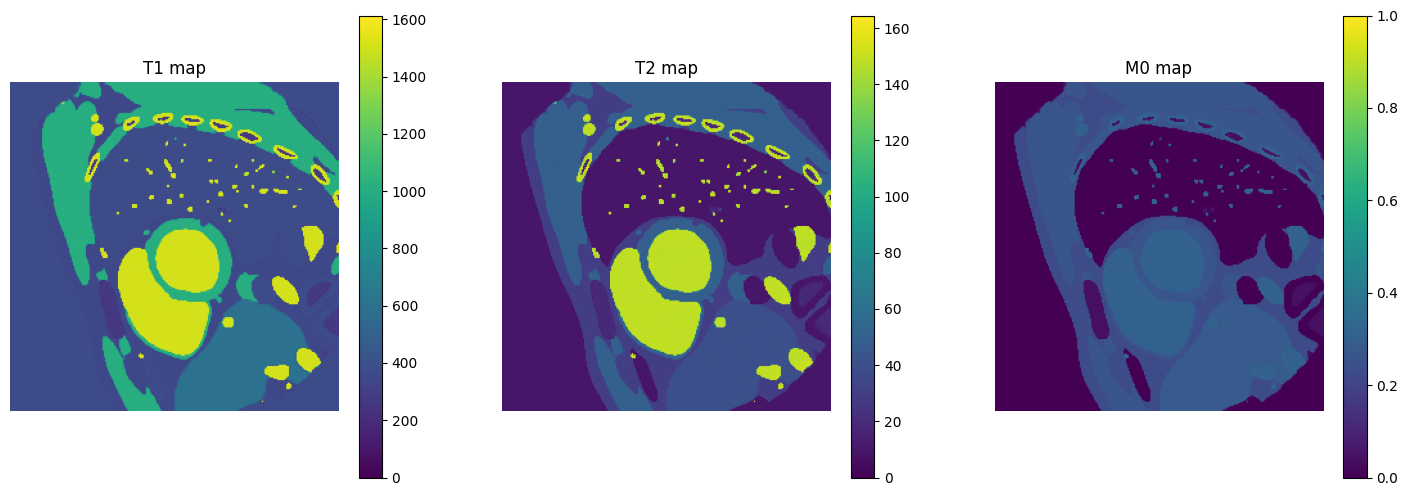

In [50]:
plt.figure(figsize=(18,6));
plt.subplot(1,3,1);
plt.title("T1 map")
plt.imshow(T1,vmin=0,cmap="viridis");plt.axis('off');
plt.colorbar()
plt.subplot(1,3,2);
plt.title("T2 map")
plt.imshow(T2,vmin=0,cmap="viridis");plt.axis('off');
plt.colorbar()
plt.subplot(1,3,3);
plt.title("M0 map")
plt.imshow(np.abs(M0),vmin=0,vmax=1,cmap='viridis'); plt.axis('off');
plt.colorbar()
plt.show();

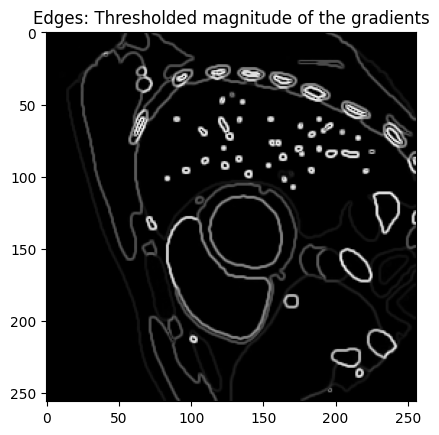

In [35]:
# Compute gradient magnitude across all feature maps
def gradient_magnitude(arr):
    arr_norm = normalize(arr)
    gx = sobel(arr_norm, axis=1)   # horizontal gradient
    gy = sobel(arr_norm, axis=0)   # vertical gradient
    return np.sqrt(gx**2 + gy**2)

# accumulate gradients across all maps
grad  = gradient_magnitude(T1)
grad += gradient_magnitude(T2)
grad /= grad.max()
#grad = grad > 0.05

plt.figure()
plt.imshow(grad, cmap = "grey")
plt.title("Edges: Thresholded magnitude of the gradients")
plt.show()

## Begin segmentation

T1 myo mid: 0.9335158 T1 myo std 0.050000012
T2 myo mid: 0.89790684 T2 myo std 0.01999998
Adding terminal edges...
Adding pixel-to-pixel edges...
Running max-flow...
Extracting segment map...


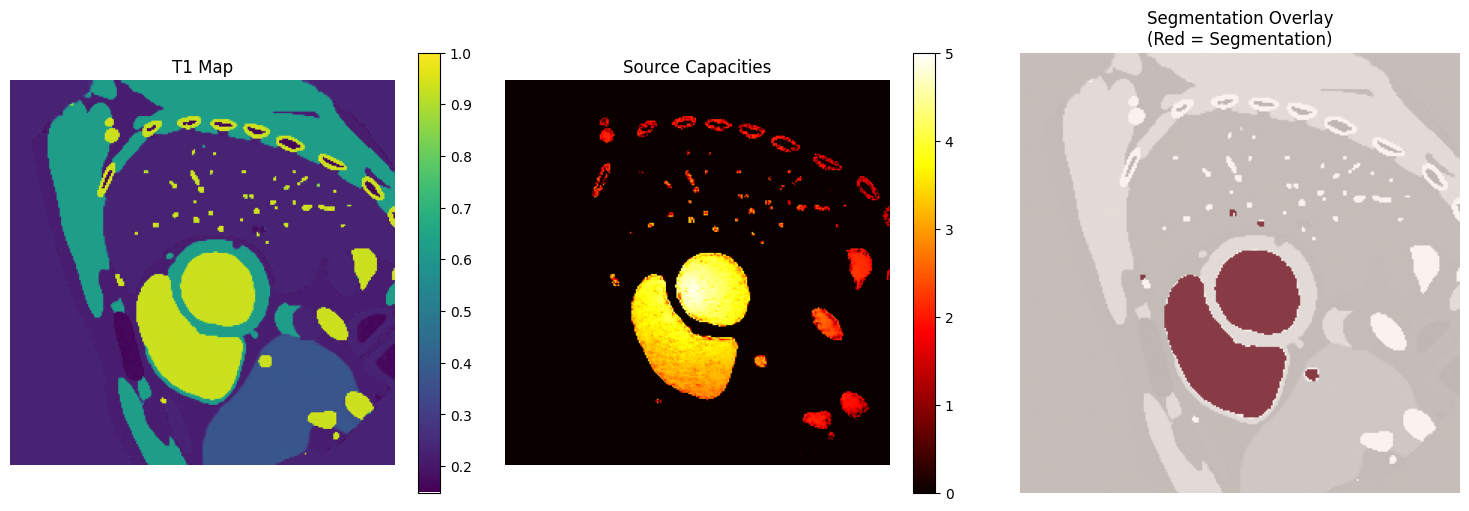

In [43]:
#key_point_range = [130, 100] # 2ch blood
#key_point_loc = [130, 100] # same to just segment the blood

#key_point_range = [140, 175] # 4ch blood
#key_point_loc = [140, 175]

#key_point_range = [151, 121] # sax blood
#key_point_loc = [151, 121]

key_point_range = [140, 125] # sax ventricles blood
key_point_loc = [140, 125]

param_weights = (1, 1, 1, 1, 0)
lambda_terminal = 5.0 # Soft membership scaling
spatial_scale = 60 # 10 for noisy, 60 for clean

T1_norm = normalize(T1)
T2_norm = normalize(T2)
M0_norm = normalize(M0)
Im_norm = normalize(Im)

H, W = T1_norm.shape
grad_0 = np.zeros_like(grad)

segment_heart, capacity_total, source_caps = segmentation_pipeline(T1_norm, T2_norm, np.abs(M0_norm), np.abs(Im_norm),
                                                                              param_weights, key_point_range, key_point_loc, lambda_terminal, grad_0, spatial_scale)

visualize_segmentation(segment_heart, T1_norm, capacity_total[H*W,0:H*W].reshape(H, W))

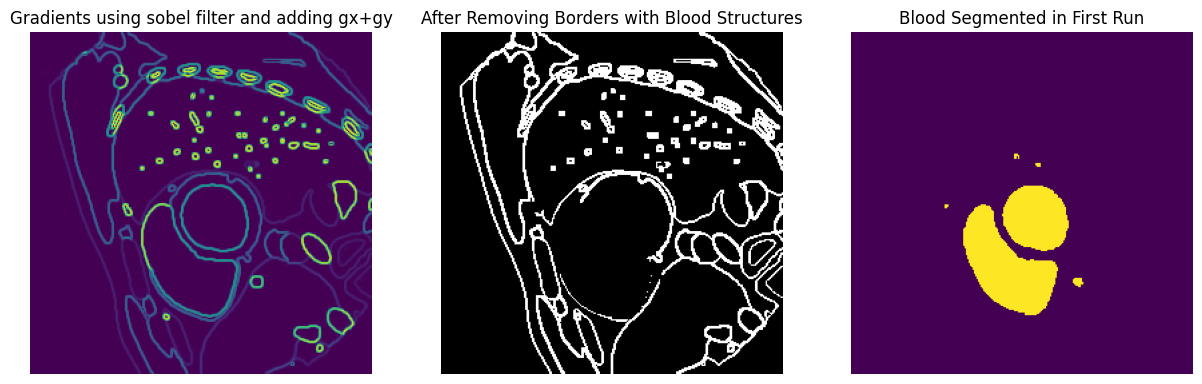

In [44]:
# make gradients disappear when sharing edges with the heart
grad_less = np.copy(grad)
for i in range(H-3):
  for j in range(W-3):
    if (grad[i,j] > 0):
      if (np.sum(segment_heart[i-3:i+3,j-3:j+3]) > 0):
        grad_less[i,j] = 0

grad_less = grad_less > 0.05 # threshold for binary edges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(grad)
axes[0].set_title("Gradients using sobel filter and adding gx+gy")
axes[0].set_axis_off()

im1 = axes[1].imshow(grad_less, cmap='gray')
axes[1].set_title("After Removing Borders with Blood Structures")
axes[1].set_axis_off()

im2 = axes[2].imshow(segment_heart)
axes[2].set_title("Blood Segmented in First Run")
axes[2].set_axis_off()

plt.show()

T1 myo mid: 0.6252536 T1 myo std 0.050000012
T2 myo mid: 0.30492544 T2 myo std 0.02000001
Adding terminal edges...
Adding pixel-to-pixel edges...
Running max-flow...
Extracting segment map...


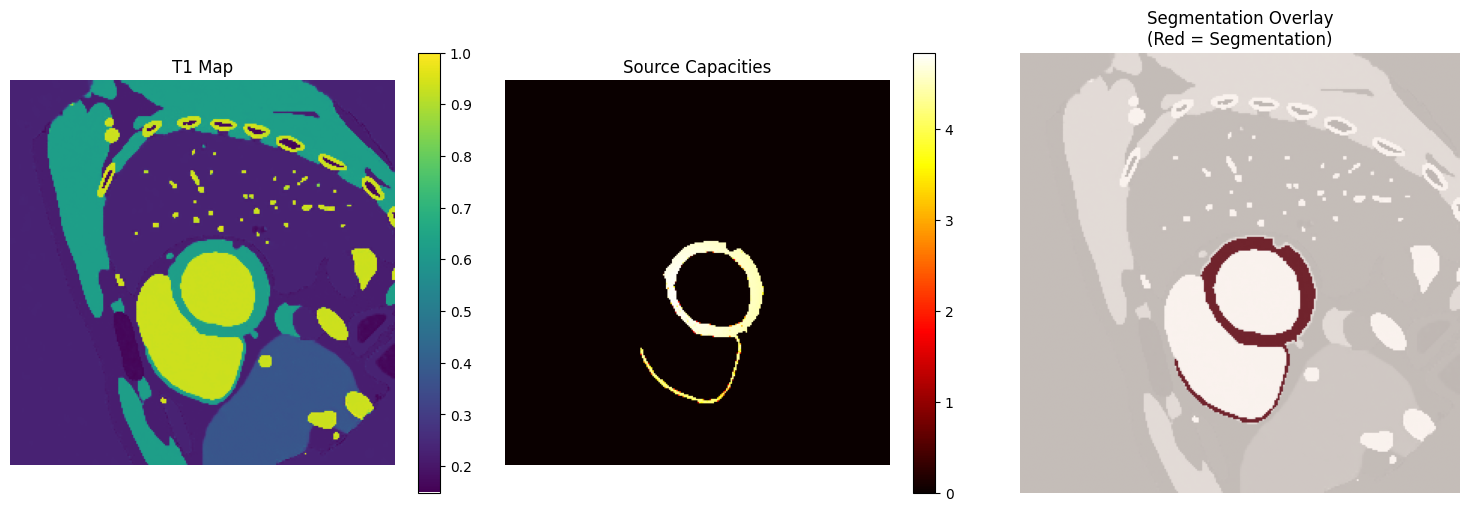

In [46]:
param_weights = (5, 5, 1, 1, 0)
lambda_terminal = 5.0 # Soft membership scaling
spatial_scale = 20

#key_point_loc = [175, 110] # location used to calculate line
#key_point_loc = [130, 100] # 2ch blood
#key_point_range = [125, 115] # ventricle view location used to determine range
#key_point_range = [150, 52] # 2ch myocardium

#key_point_loc = [140, 175] # 4ch blood
#key_point_loc = [133, 160]
#key_point_range = [130, 225] # 4ch myocardium

#key_point_range = [191, 102] # sax
#key_point_loc = [132, 136] # sax

key_point_range = [146, 166] # sax ventricles

segment_map_myo1, capacity_total_myo1, _ = segmentation_pipeline(T1_norm, T2_norm, np.abs(M0_norm), np.abs(Im_norm),
                                                                    param_weights, key_point_range, key_point_loc, lambda_terminal, grad_less, spatial_scale)
visualize_segmentation(segment_map_myo1, T1_norm, capacity_total_myo1[H*W,0:H*W].reshape(H, W))

T1 myo mid: 0.6252536 T1 myo std 0.050000012
T2 myo mid: 0.30492544 T2 myo std 0.02000001
Adding terminal edges...
Adding pixel-to-pixel edges...
Running max-flow...
Extracting segment map...


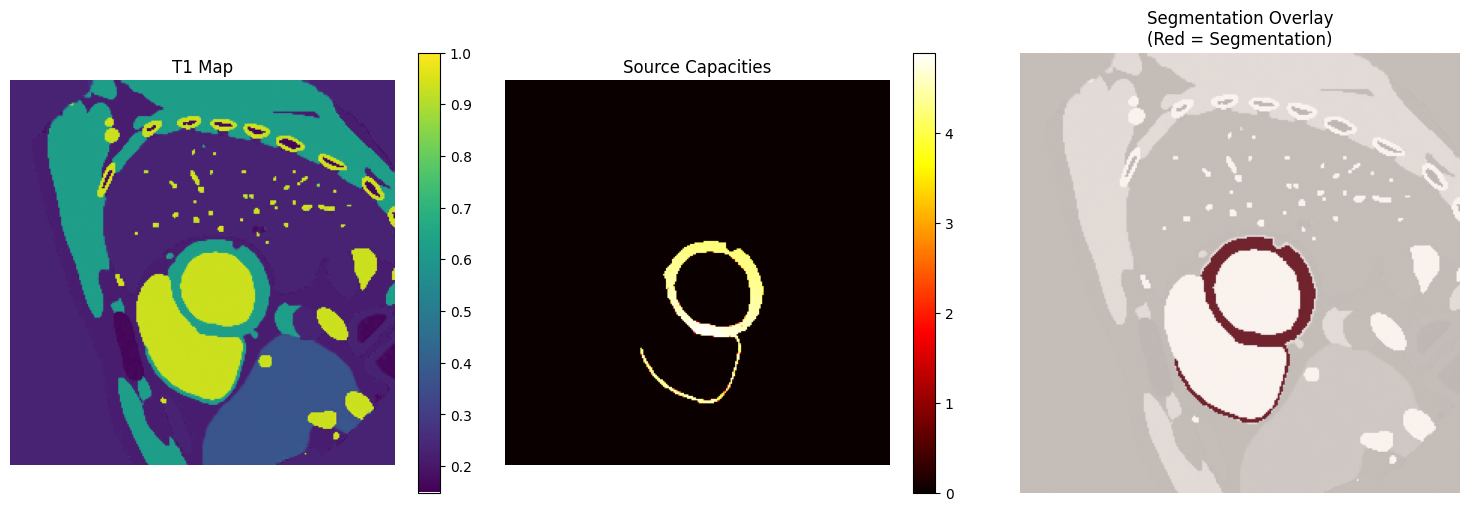

In [47]:
# repeat with a second or third location to see the full view of the myocardium
#key_point_loc = [174, 95] # location used to calculate line, 2ch noisy, blood
#key_point_loc = [140, 224] # 4ch
key_point_loc = [175, 127] # sax

segment_map_myo2, capacity_total_myo2, _ = segmentation_pipeline(T1_norm, T2_norm, np.abs(M0_norm), np.abs(Im_norm),
                                                                    param_weights, key_point_range, key_point_loc, lambda_terminal, grad_less, spatial_scale)

visualize_segmentation(segment_map_myo2, T1_norm, capacity_total_myo2[H*W,0:H*W].reshape(H, W))

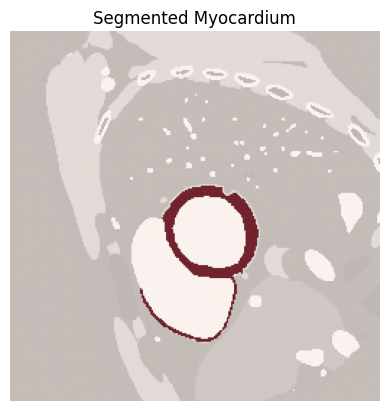

In [49]:
final_seg = np.logical_or(segment_map_myo1, segment_map_myo1)
plt.figure()
plt.imshow(T1_norm, cmap='gray')
plt.imshow(final_seg, cmap='Reds', alpha=0.75)
plt.title('Segmented Myocardium')
plt.axis('off')
plt.show()